In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error


In [20]:
df = pd.read_csv("Sales_April_2019.csv")
print("2019 April sales dataset : \n")
display(df)


2019 April sales dataset : 



,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
18378,194090,Google Phone,1,600,04/08/19 17:11,"177 Jackson St, Los Angeles, CA 90001"
18379,194091,AA Batteries (4-pack),1,3.84,04/15/19 16:02,"311 Forest St, Austin, TX 73301"
18380,194092,AAA Batteries (4-pack),2,2.99,04/28/19 14:36,"347 Sunset St, San Francisco, CA 94016"
18381,194093,AA Batteries (4-pack),1,3.84,04/14/19 15:09,"835 Lake St, Portland, OR 97035"


In [21]:
df = df.dropna()
print("Dataset after removing tuples with missing values : \n")
display(df)


Dataset after removing tuples with missing values : 



,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001"
...,...,...,...,...,...,...
18378,194090,Google Phone,1,600,04/08/19 17:11,"177 Jackson St, Los Angeles, CA 90001"
18379,194091,AA Batteries (4-pack),1,3.84,04/15/19 16:02,"311 Forest St, Austin, TX 73301"
18380,194092,AAA Batteries (4-pack),2,2.99,04/28/19 14:36,"347 Sunset St, San Francisco, CA 94016"
18381,194093,AA Batteries (4-pack),1,3.84,04/14/19 15:09,"835 Lake St, Portland, OR 97035"


In [22]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each'] = pd.to_numeric(df['Price Each'], errors='coerce')
df = df.dropna()


C:\Users\Admin\AppData\Local\Temp\ipykernel_12712\3304865004.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')


In [23]:
df['Total Sales'] = df['Quantity Ordered'] * df['Price Each']
df['Date'] = df['Order Date'].dt.date
df[['Date', 'Total Sales']].head()

print("Created total sales column :\n")
df.head()


Created total sales column :



,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Total Sales,Date
0,176558,USB-C Charging Cable,2.0,11.95,2019-04-19 08:46:00,"917 1st St, Dallas, TX 75001",23.90,2019-04-19
2,176559,Bose SoundSport Headphones,1.0,99.99,2019-04-07 22:30:00,"682 Chestnut St, Boston, MA 02215",99.99,2019-04-07
3,176560,Google Phone,1.0,600.00,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",600.00,2019-04-12
4,176560,Wired Headphones,1.0,11.99,2019-04-12 14:38:00,"669 Spruce St, Los Angeles, CA 90001",11.99,2019-04-12
5,176561,Wired Headphones,1.0,11.99,2019-04-30 09:27:00,"333 8th St, Los Angeles, CA 90001",11.99,2019-04-30


In [24]:
daily_sales = df.groupby('Date')['Total Sales'].sum().reset_index()
daily_sales.head()


,Date,Total Sales
0,2019-04-01,107527.34
1,2019-04-02,104496.71
2,2019-04-03,113611.75
3,2019-04-04,116214.99
4,2019-04-05,114012.88


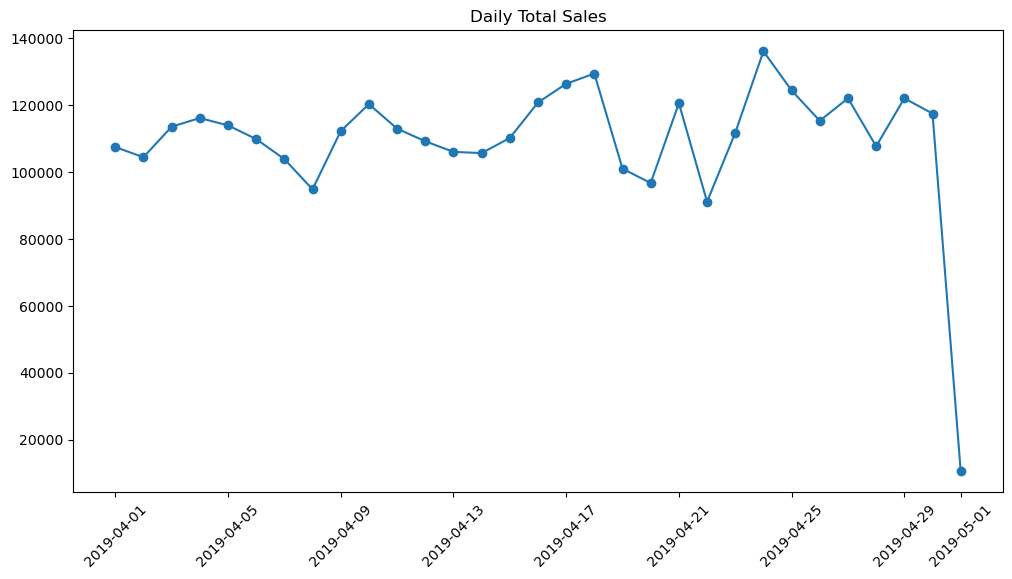

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(daily_sales['Date'], daily_sales['Total Sales'], marker='o')
plt.xticks(rotation=45)
plt.title("Daily Total Sales")
plt.show()


In [26]:
daily_sales.set_index('Date', inplace=True)

model = ARIMA(daily_sales['Total Sales'], order=(2, 1, 2))
model_fit = model.fit()
model_fit.summary()


D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
D:\Anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:            Total Sales   No. Observations:                   31
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -341.451
Date:                Wed, 09 Jul 2025   AIC                            692.902
Time:                        15:37:04   BIC                            699.908
Sample:                    04-01-2019   HQIC                           695.143
                         - 05-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1698      0.261     -4.477      0.000      -1.682      -0.658
ar.L2         -0.9834      0.189     -5.209      0.000      -1.353      -0.613
ma.L1          1.2125      0.750      1.617      0.106      -0.257       2.682
ma.L2          0.9724      0.466      2.088      0.037       0.060       1.885
sigma2      5.403e+08   1.93e-09   2.79e+17      0.000     5.4e+08     5.4e+08
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):               192.15
Prob(Q):                              0.90   Prob(JB):                         0.00
Heteroskedasticity (H):              11.32   Skew:                            -2.92
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.94
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.82e+34. Standard errors may be unstable.
"""

In [27]:
forecast = model_fit.forecast(steps=7)
print("Forecast for the next 7 days : \n")
display(forecast)


Forecast for the next 7 days : 



2019-05-02    16917.624190
2019-05-03    24748.444236
2019-05-04     9335.674912
2019-05-05    19664.319062
2019-05-06    22738.737483
2019-05-07     8985.532391
2019-05-08    22050.186161
Freq: D, Name: predicted_mean, dtype: float64

In [28]:
predicted = model_fit.predict(start=1, end=len(daily_sales)-1)
actual = daily_sales['Total Sales'][1:]
mape = mean_absolute_percentage_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
print("Mean absolute percentage error : ", mape)
print("Root mean squared error : ", rmse)


Mean absolute percentage error :  0.3783394592775629
Root mean squared error :  20675.113600007193


In [29]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

values = daily_sales['Total Sales'].values.reshape(-1, 1)

scaler = MinMaxScaler()
scaled_values = scaler.fit_transform(values)

X, y = [], []
for i in range(3, len(scaled_values)):
    X.append(scaled_values[i-3:i])
    y.append(scaled_values[i])

X = np.array(X)
y = np.array(y)


In [30]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


In [31]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(3, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

model.fit(X_train, y_train, epochs=50, verbose=0)


D:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [32]:
forecast_input = scaled_values[-3:].reshape(1, 3, 1)

forecast_lstm = []
for _ in range(7):
    next_val = model.predict(forecast_input)[0][0]
    forecast_lstm.append(next_val)
    forecast_input = np.append(forecast_input[:, 1:, :], [[[next_val]]], axis=1)

forecast_lstm = scaler.inverse_transform(np.array(forecast_lstm).reshape(-1, 1))
print("LSTM Forecast for Next 7 Days:")
print(forecast_lstm.flatten())


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
LSTM Forecast for Next 7 Days:
[42796.55  36568.84  30972.08  32314.865 31532.643 31164.762 31169.236]


In [33]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test)
y_pred_inv = scaler.inverse_transform(y_pred)

rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mape_lstm = mean_absolute_percentage_error(y_test_inv, y_pred_inv)

print("LSTM RMSE:", rmse_lstm)
print("LSTM MAPE:", mape_lstm)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
LSTM RMSE: 59848.880745320195
LSTM MAPE: 1.1178593495955964
